In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo
import astropy
from astropy.table import Table
from astropy.io import fits
import seaborn as sns
from matplotlib.animation import PillowWriter

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]
linestyles = ['-', '--', ':', '-.']

In [2]:
import pandas as pd
from astropy.io import fits
from astropy.table import Table

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

def compute_binned_median(df, x_col, y_col, n_bins=12):
    """
    Bin df[x_col] into n_bins, then compute median of df[y_col] in each bin,
    and also return the number of points in each bin.

    Returns columns:
    ['x_bin', f'{y_col}_median', 'x_center', 'count']
    """
    
    # Create bins
    x_bins = np.linspace(df[x_col].min(), df[x_col].max(), n_bins + 1)

    # Bin using pd.cut
    x_bin_labels = pd.cut(df[x_col], bins=x_bins, include_lowest=True)

    # Group by bins and compute median AND count
    grouped = df.groupby(x_bin_labels).agg(
        y_median=(y_col, 'median'),
        count=(y_col, 'size')
    ).reset_index()

    # Add x_center using bin midpoint
    grouped['x_center'] = grouped[x_col].apply(lambda interval: interval.mid)

    # Rename bin column
    grouped = grouped.rename(columns={x_col: 'x_bin', 'y_median': f"{y_col}_median"})

    return grouped


In [3]:
with fits.open('../../data/astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

two_process_data = fitsrec_to_pandas(twoprocess_data)
data_astronn = fitsrec_to_pandas(astronn_data)

# Identify columns that are NOT already in two_process_data
new_cols = data_astronn.columns.difference(two_process_data.columns)

# Concatenate, keeping two_process_data's versions of duplicate columns
data = pd.concat(
    [
        two_process_data.reset_index(drop=True),
        data_astronn[new_cols].reset_index(drop=True)
    ],
    axis=1
)

data = data[data['DFLAG'] == 0]

data['MG_H'] = data['MG_H_ASPCAP_ADJ']
data['FE_H'] = data['FE_H_ASPCAP_ADJ']
data['MN_H'] = data['MN_H_ASPCAP_ADJ']

data['MN_O'] = data['MN_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['FE_O'] = data['FE_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['MN_MG'] = data['MN_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['FE_MG'] = data['FE_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['MG_FE'] = data['MG_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['MN_FE'] = data['MN_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])

# Create FE_H range arrays
feh_neg = np.linspace(data['FE_H'].min(), 0, 300)  # negative metallicity
feh_pos = np.linspace(0, data['FE_H'].max(), 300)  # positive metallicity

# Compute boundary line
mgfe_neg = 0.12 - 0.13 * feh_neg        # sloped part
mgfe_pos = np.full_like(feh_pos, 0.12)  # flat part at +0.12
feh_line = np.concatenate([feh_neg, feh_pos])
mgfe_line = np.concatenate([mgfe_neg, mgfe_pos])
mgh_line = mgfe_line + feh_line
femg_line = feh_line - mgh_line

data_low_alpha = data_low_alpha[(data_low_alpha['galz'] < 2) & (data_low_alpha['galz'] > -2) &
                                (data_low_alpha['galr'] < 15) & (data_low_alpha['galr'] > 3)]

data_high_alpha = data_high_alpha[(data_high_alpha['galz'] < 2) & (data_high_alpha['galz'] > -2) &
                                (data_high_alpha['galr'] < 15) & (data_high_alpha['galr'] > 3)]

mnmg_high = compute_binned_median(data_high_alpha, x_col='MG_H', y_col='MN_MG', n_bins=20)
mnmg_low = compute_binned_median(data_low_alpha, x_col='MG_H', y_col='MN_MG', n_bins=20)
femg_high = compute_binned_median(data_high_alpha, x_col='MG_H', y_col='FE_MG', n_bins=20)
femg_low = compute_binned_median(data_low_alpha, x_col='MG_H', y_col='FE_MG', n_bins=20)

mnmg_high = mnmg_high[mnmg_high['count'] >= 100]
mnmg_low  = mnmg_low[mnmg_low['count']  >= 100]
femg_high = femg_high[femg_high['count'] >= 100]
femg_low  = femg_low[femg_low['count']  >= 100]

data_high_alpha['high_low_alpha'] = "high"
data_low_alpha['high_low_alpha'] = "low"
data_high_alpha['color'] = "hotpink"
data_low_alpha['color'] = "cornflowerblue"

data_all = pd.concat([data_high_alpha, data_low_alpha], ignore_index=True)

data_all = data_all[data_all['zmax'] < 5]

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_17919/3137802370.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(x_bin_labels).agg(
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_17919/3137802370.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(x_bin_labels).agg(
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_17919/3137802370.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the 

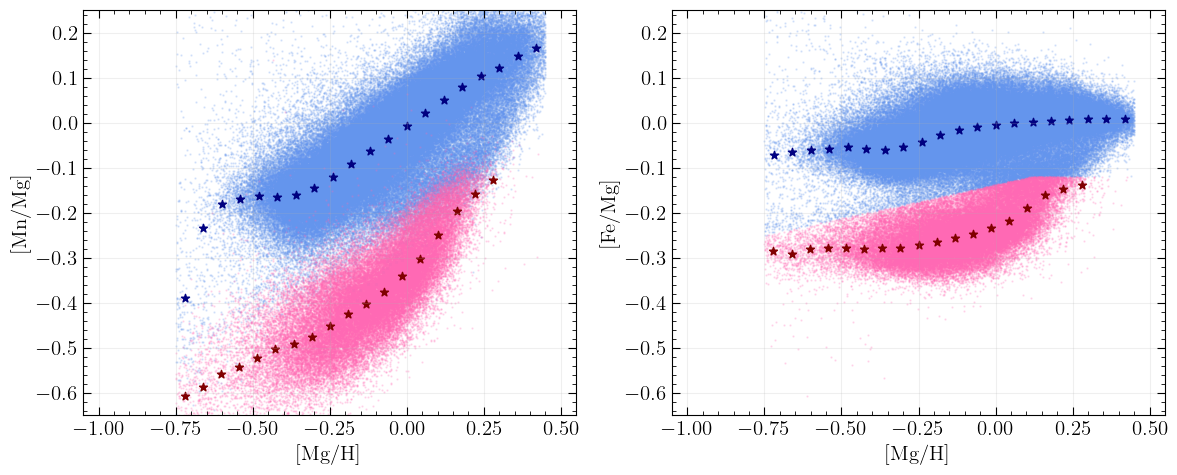

In [4]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.2, color = 'hotpink', s = 0.5)


plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'navy')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'maroon')

plt.grid('True', alpha = 0.2)

plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.2, color = 'hotpink', s = 0.5)


plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'navy')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'maroon')

plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

In [5]:
mg_h_bin_edges = np.arange(-0.6, 0.3, 0.1) 
mg_h_big_bin_edges = np.arange(-1.0, 1.0, 0.2) 

data_all['MG_H_bin'] = pd.cut(data_all['MG_H'], bins = mg_h_bin_edges, right=False, labels=False)
data_all['MG_H_big_bin'] = pd.cut(data_all['MG_H'], bins = mg_h_big_bin_edges, right=False, labels=False)

xs = np.linspace(-1, 1, 100)

def downsample(df, N):
    if len(df) > N:
        return df.sample(N, random_state=42)   # random subset of N
    else:
        return df
    
t_array = np.linspace(0.0001,14,int(1e3))
dt = t_array[1] - t_array[0]

In [6]:
m_g_array_const = np.ones(len(t_array))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
m_g_array_exp /= np.trapezoid(m_g_array_exp, t_array)

etas = [0, 0.5, 1]
tau_stars = [0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 6]
colors_lines = ['blue', 'orange', 'green', 'red', 'purple', 'teal', 'magenta', 'brown', 'navy', 'maroon']
colors_dots = ['greenyellow', 'cyan', 'orange', 'blue', 'red', 'yellow', 'green', 'gray', 'peru', 'navy']


def rise_fall(t, tau_1, tau_2):
    return 1 * (1 - np.exp(-t/tau_1)) * np.exp(-t/tau_2)

tau_1s = [2, 5, 5]
tau_2s = [6, 10, 20]
sfr_1 = rise_fall(t_array, tau_1s[0], tau_2s[0])
sfr_2 = rise_fall(t_array, tau_1s[1], tau_2s[1])
sfr_3 = rise_fall(t_array, tau_1s[2], tau_2s[2])
mask_1 = t_array > 6
sfr_1[mask_1] = 1e-6

# Normalize each SFR so integral over time equals 1
sfr_1 /= np.trapezoid(sfr_1, t_array)
sfr_2 /= np.trapezoid(sfr_2, t_array)
sfr_3 /= np.trapezoid(sfr_3, t_array)

sfrs = [sfr_1, sfr_2, sfr_3]


gals_taustar_eta0 = []
gals_taustar_eta1 = []
gals_taustar_eta2 = []

#gals_taustar_sfrconst = []
gals_taustar_sfrexp = []
gals_taustar_sfr1 = []
gals_taustar_sfr2 = []
gals_taustar_sfr3 = []


gals_eta = []
gals_sfr = []


for i in range(len(tau_stars)):
    gals_taustar_eta0.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0]))

for i in range(len(tau_stars)):
    gals_taustar_eta1.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[1]))

for i in range(len(tau_stars)):
    gals_taustar_eta2.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[2]))



for i in range(len(tau_stars)):
    gals_taustar_sfrexp.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_exp, tau_star=tau_stars[i], eta=etas[0]))

for i in range(len(tau_stars)):
    gals_taustar_sfr1.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=sfrs[0], tau_star=tau_stars[i], eta=etas[0]))

for i in range(len(tau_stars)):
    gals_taustar_sfr2.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=sfrs[1], tau_star=tau_stars[i], eta=etas[0]))

for i in range(len(tau_stars)):
    gals_taustar_sfr3.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=sfrs[2], tau_star=tau_stars[i], eta=etas[0]))



for j in range(len(etas)):
    gals_eta.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_const, tau_star=1, eta=etas[j]))

for k in range(len(sfrs)):
    gals_sfr.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=sfrs[k], tau_star=1, eta=0))

Text(0, 0.5, 'SFR')

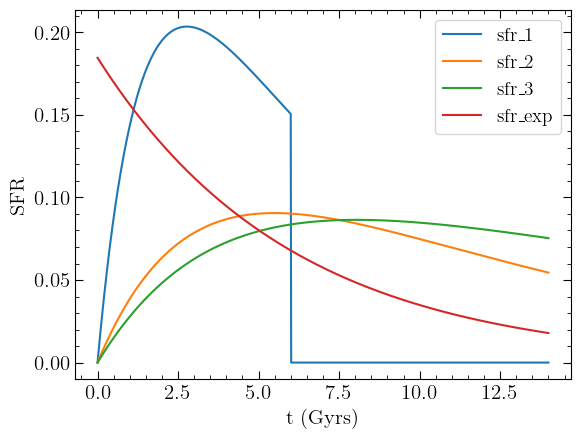

In [7]:
for i in range(len(sfrs)):
    plt.plot(t_array, sfrs[i], label = f'sfr_{i+1}')

plt.plot(t_array, m_g_array_exp, label = r'sfr_{exp}')
plt.legend(loc = 'upper right')
plt.xlabel('t (Gyrs)')
plt.ylabel('SFR')

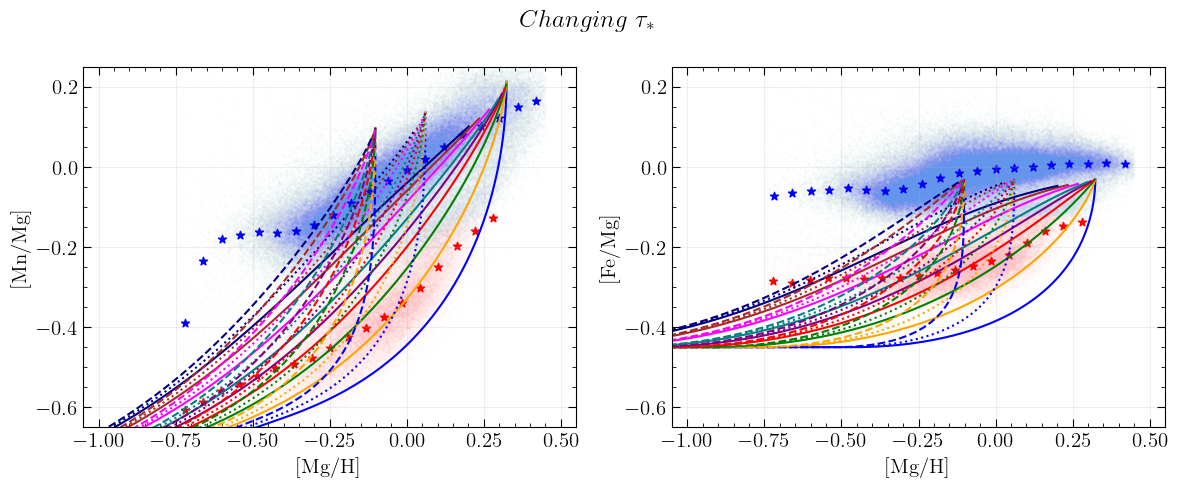

In [8]:
fig = plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.01, color = 'pink', s = 0.5)
plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'blue')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'red')

for i in range(len(gals_taustar_eta0)):
    gal = gals_taustar_eta0[i]
    plt.plot(gal.O_H, gal.Mn_O, label = 'Mn, default met dep', color = colors_lines[i], linestyle='-')

for i in range(len(gals_taustar_eta1)):
    gal = gals_taustar_eta1[i]
    plt.plot(gal.O_H, gal.Mn_O, label = 'Mn, default met dep', color = colors_lines[i], linestyle=':')


for i in range(len(gals_taustar_eta2)):
    gal = gals_taustar_eta2[i]
    plt.plot(gal.O_H, gal.Mn_O, label = 'Mn, default met dep', color = colors_lines[i], linestyle='--')



#fig.legend(loc="upper right", bbox_to_anchor=(0.5, 1.05), ncol=3)
plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.01, color = 'pink', s = 0.5)
plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'blue')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'red')

for i in range(len(gals_taustar_eta0)):
    gal = gals_taustar_eta0[i]
    plt.plot(gal.O_H, gal.Fe_O, label = rf'const SFR, $\tau_* = {gal.tau_star_arr[0]} , \eta = {gal.eta_arr[0]} $', color = colors_lines[i])

for i in range(len(gals_taustar_eta1)):
    gal = gals_taustar_eta1[i]
    plt.plot(gal.O_H, gal.Fe_O, label = rf'const SFR, $\tau_* = {gal.tau_star_arr[0]} , \eta = {gal.eta_arr[0]} $', color = colors_lines[i], linestyle=':')


for i in range(len(gals_taustar_eta2)):
    gal = gals_taustar_eta2[i]
    plt.plot(gal.O_H, gal.Fe_O, label = rf'const SFR, $\tau_* = {gal.tau_star_arr[0]} , \eta = {gal.eta_arr[0]} $', color = colors_lines[i], linestyle='--')


plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)

#plt.legend(bbox_to_anchor=[1, 0.5])

plt.suptitle(r"$Changing \ \tau_*$")
plt.tight_layout()

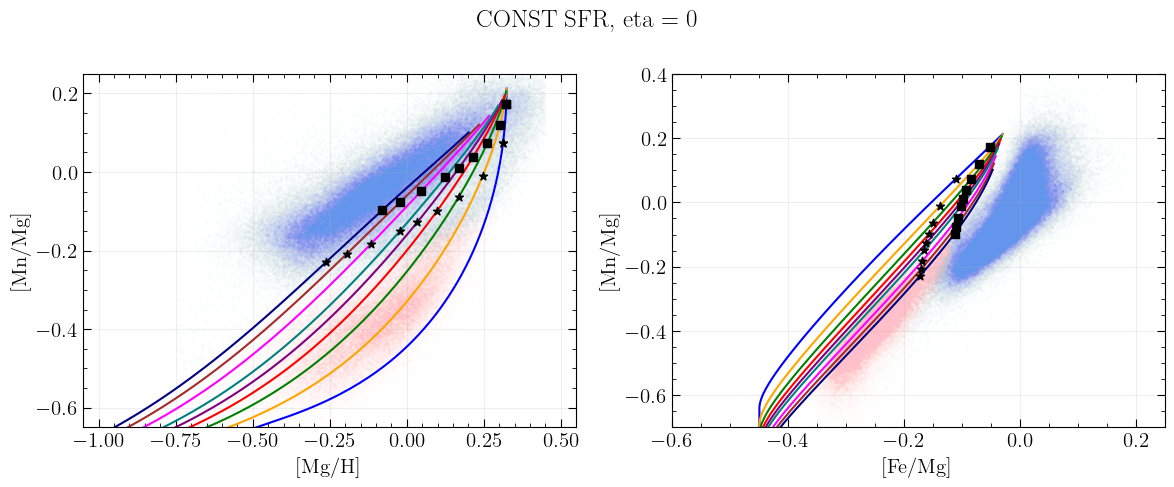

In [9]:
fig = plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.01, color = 'pink', s = 0.5)


for i in range(len(gals_taustar_eta0)):
    gal = gals_taustar_eta0[i]
    plt.plot(gal.O_H, gal.Mn_O, color = colors_lines[i], linestyle='-')

    idx_3 = np.argmin(np.abs(gal.t - 3))
    idx_5 = np.argmin(np.abs(gal.t - 5))

    if i == 0:
        plt.scatter(gal.O_H[idx_3], gal.Mn_O[idx_3], marker='*', zorder=10, color = 'black', label = 't = 3 Gyrs')
        plt.scatter(gal.O_H[idx_5], gal.Mn_O[idx_5], marker='s', zorder=10, color = 'black', label = 't = 5 Gyrs')
    plt.scatter(gal.O_H[idx_3], gal.Mn_O[idx_3], marker='*', zorder=10, color = 'black')
    plt.scatter(gal.O_H[idx_5], gal.Mn_O[idx_5], marker='s', zorder=10, color = 'black')

#plt.legend()
plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['FE_MG'], data_low_alpha['MN_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['FE_MG'], data_high_alpha['MN_MG'], alpha = 0.01, color = 'pink', s = 0.5)

for i in range(len(gals_taustar_eta0)):
    gal = gals_taustar_eta0[i]
    plt.plot(gal.Fe_Mg[1:], gal.Mn_Mg[1:], label = rf'$\tau_* = {gal.tau_star_arr[0]}$', color = colors_lines[i])

    idx_3 = np.argmin(np.abs(gal.t - 3))
    idx_5 = np.argmin(np.abs(gal.t - 5))

    plt.scatter(gal.Fe_Mg[idx_3], gal.Mn_Mg[idx_3], marker='*', zorder=10, color = 'black')
    plt.scatter(gal.Fe_Mg[idx_5], gal.Mn_Mg[idx_5], marker='s', zorder=10, color = 'black')

plt.grid('True', alpha = 0.2)
plt.xlabel('[Fe/Mg]')
plt.ylabel('[Mn/Mg]')
plt.xlim(65,0.25)
plt.xlim(-0.60, 0.25)
plt.ylim(-0.70, 0.40)

#plt.legend(bbox_to_anchor=[1, 1])

plt.suptitle(r"CONST SFR, eta = 0")
plt.tight_layout()

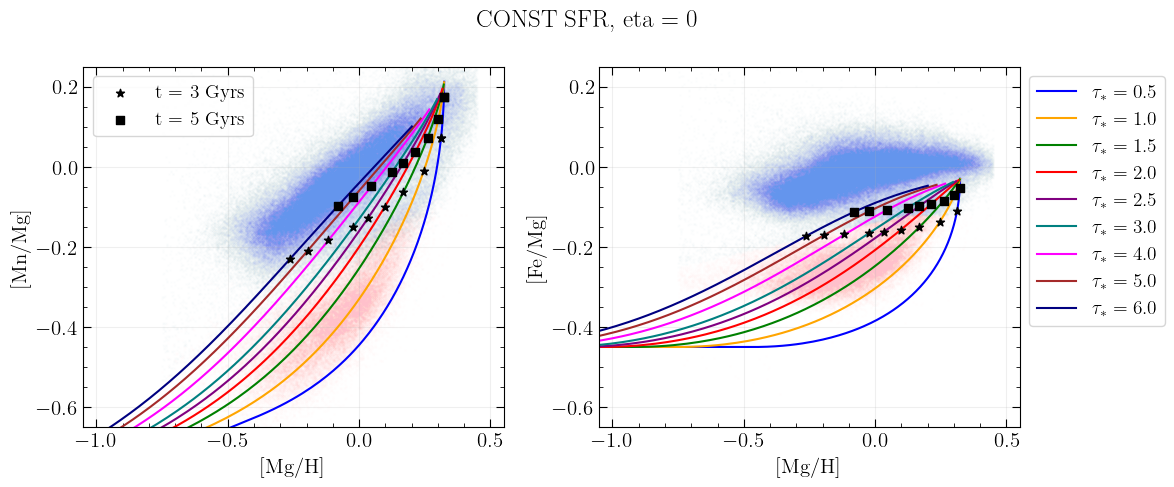

In [10]:
fig = plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.01, color = 'pink', s = 0.5)


for i in range(len(gals_taustar_eta0)):
    gal = gals_taustar_eta0[i]
    plt.plot(gal.O_H, gal.Mn_O, color = colors_lines[i], linestyle='-')

    idx_3 = np.argmin(np.abs(gal.t - 3))
    idx_5 = np.argmin(np.abs(gal.t - 5))

    if i == 0:
        plt.scatter(gal.O_H[idx_3], gal.Mn_O[idx_3], marker='*', zorder=10, color = 'black', label = 't = 3 Gyrs')
        plt.scatter(gal.O_H[idx_5], gal.Mn_O[idx_5], marker='s', zorder=10, color = 'black', label = 't = 5 Gyrs')
    plt.scatter(gal.O_H[idx_3], gal.Mn_O[idx_3], marker='*', zorder=10, color = 'black')
    plt.scatter(gal.O_H[idx_5], gal.Mn_O[idx_5], marker='s', zorder=10, color = 'black')

plt.legend()
plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.01, color = 'pink', s = 0.5)

for i in range(len(gals_taustar_eta0)):
    gal = gals_taustar_eta0[i]
    plt.plot(gal.Mg_H[1:], gal.Fe_Mg[1:], label = rf'$\tau_* = {gal.tau_star_arr[0]}$', color = colors_lines[i])

    idx_3 = np.argmin(np.abs(gal.t - 3))
    idx_5 = np.argmin(np.abs(gal.t - 5))

    plt.scatter(gal.Mg_H[idx_3], gal.Fe_Mg[idx_3], marker='*', zorder=10, color = 'black')
    plt.scatter(gal.Mg_H[idx_5], gal.Fe_Mg[idx_5], marker='s', zorder=10, color = 'black')

plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.xlim(65,0.25)
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)

plt.legend(bbox_to_anchor=[1, 1])

plt.suptitle(r"CONST SFR, eta = 0")
plt.tight_layout()

In [11]:
gal = gals_taustar_eta0[0]

idx = np.argmin(np.abs(gal.t - 3))
idx

np.int64(214)

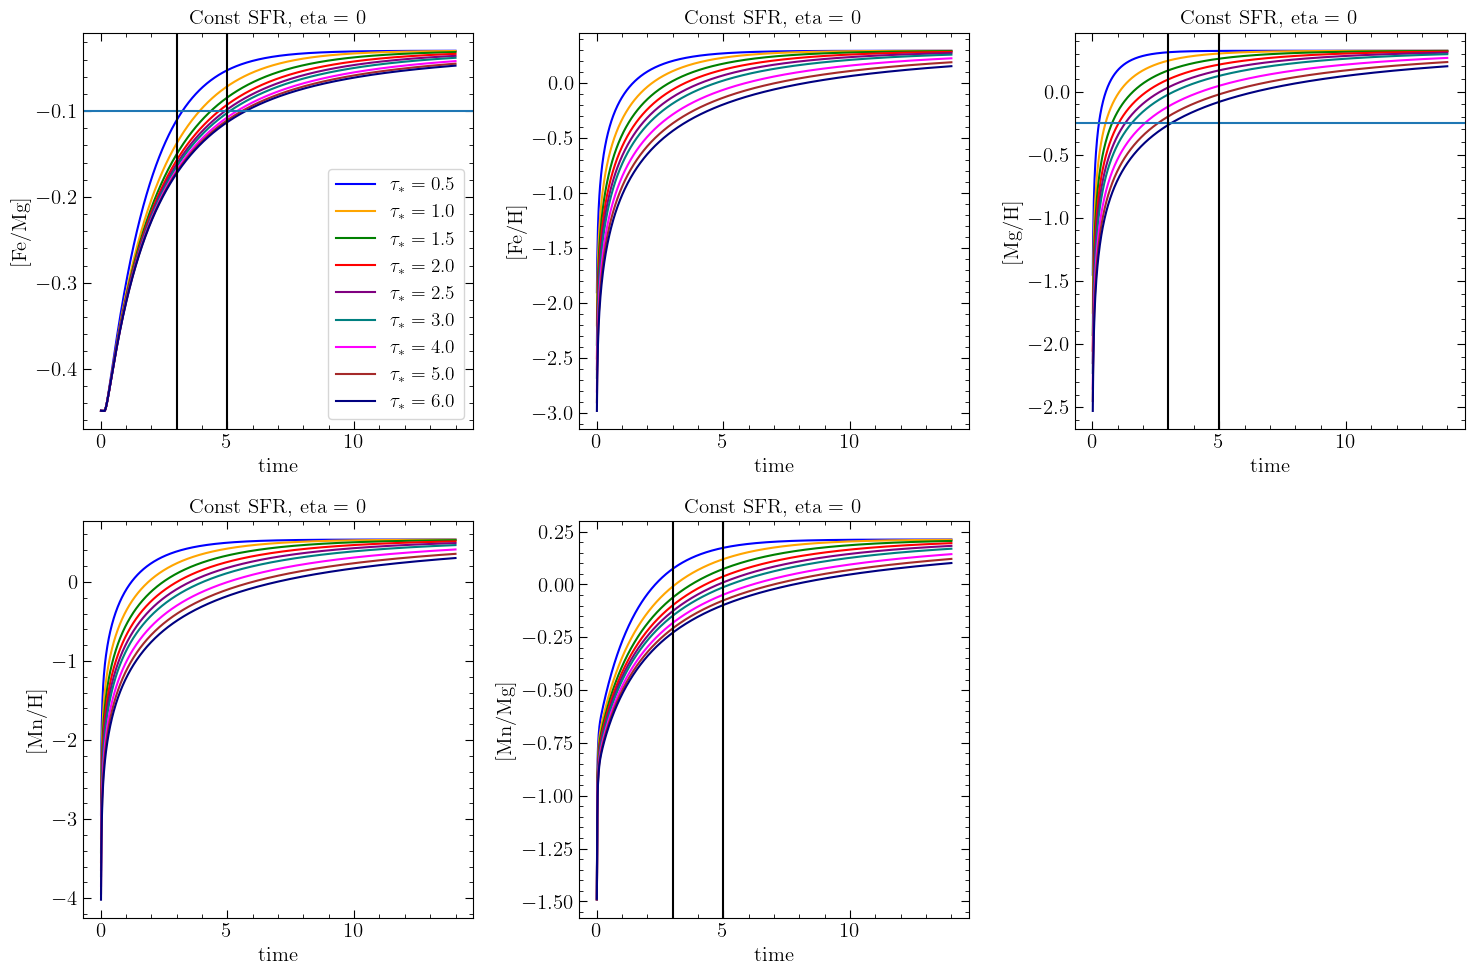

In [12]:
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
for i in range(len(gals_taustar_eta0)):
    gal = gals_taustar_eta0[i]
    plt.plot(gal.t[1:], gal.Fe_Mg[1:], label = rf'$\tau_* = {gal.tau_star_arr[0]}$', color = colors_lines[i])

plt.title("Const SFR, eta = 0")
plt.legend()
plt.axhline(-0.1)
plt.axvline(3, color = 'black')
plt.axvline(5, color = 'black')
plt.xlabel('time')
plt.ylabel('[Fe/Mg]')

plt.subplot(2,3,2)
for i in range(len(gals_taustar_eta0)):
    gal = gals_taustar_eta0[i]
    plt.plot(gal.t[1:], gal.Fe_H[1:], label = rf'$\tau_* = {gal.tau_star_arr[0]}$', color = colors_lines[i])

plt.title("Const SFR, eta = 0")
plt.xlabel('time')
plt.ylabel('[Fe/H]')

plt.subplot(2,3,3)
for i in range(len(gals_taustar_eta0)):
    gal = gals_taustar_eta0[i]
    plt.plot(gal.t[1:], gal.Mg_H[1:], label = rf'$\tau_* = {gal.tau_star_arr[0]}$', color = colors_lines[i])
plt.axhline(-0.25)
plt.title("Const SFR, eta = 0")
plt.xlabel('time')
plt.ylabel('[Mg/H]')
plt.axvline(3, color = 'black')
plt.axvline(5, color = 'black')


plt.subplot(2,3,4)
for i in range(len(gals_taustar_eta0)):
    gal = gals_taustar_eta0[i]
    plt.plot(gal.t[1:], gal.Mn_H[1:], label = rf'$\tau_* = {gal.tau_star_arr[0]}$', color = colors_lines[i])

plt.title("Const SFR, eta = 0")
plt.xlabel('time')
plt.ylabel('[Mn/H]')

plt.subplot(2,3,5)
for i in range(len(gals_taustar_eta0)):
    gal = gals_taustar_eta0[i]
    plt.plot(gal.t[1:], gal.Mn_Mg[1:], label = rf'$\tau_* = {gal.tau_star_arr[0]}$', color = colors_lines[i])

plt.title("Const SFR, eta = 0")
plt.xlabel('time')
plt.ylabel('[Mn/Mg]')
plt.axvline(3, color = 'black')
plt.axvline(5, color = 'black')


plt.tight_layout()

In [ ]:
data_all['MG_H_big_bin'] = pd.cut(data_all['MG_H'], bins = mg_h_big_bin_edges, right=False, labels=False)
colors_big_bins = ['brown', 'black', 'blue', 'green', 'hotpink', 'orange', 'red', 'turquoise', 'purple']

mg_h_big_bin_centers = 0.5 * (mg_h_big_bin_edges[:-1] + mg_h_big_bin_edges[1:])

In [14]:
def find_endpoints(galaxies, bin_centers):
    endpoints_gals = []

    for bin_cent in bin_centers:
        endpoints = []
        for gal in galaxies:
            o_h = gal.O_H
            for indx in range(len(o_h)):
                o_h_at_time = o_h[indx]
                if o_h_at_time > bin_cent:
                    endpoints.append(indx)
                    break

        endpoints_gals.append(np.array(endpoints))

    return endpoints_gals


In [15]:
gals_endpoints = {
    0: find_endpoints(gals_taustar_eta0, mg_h_big_bin_centers),
    1: find_endpoints(gals_taustar_eta1, mg_h_big_bin_centers),
    2: find_endpoints(gals_taustar_eta2, mg_h_big_bin_centers),
}

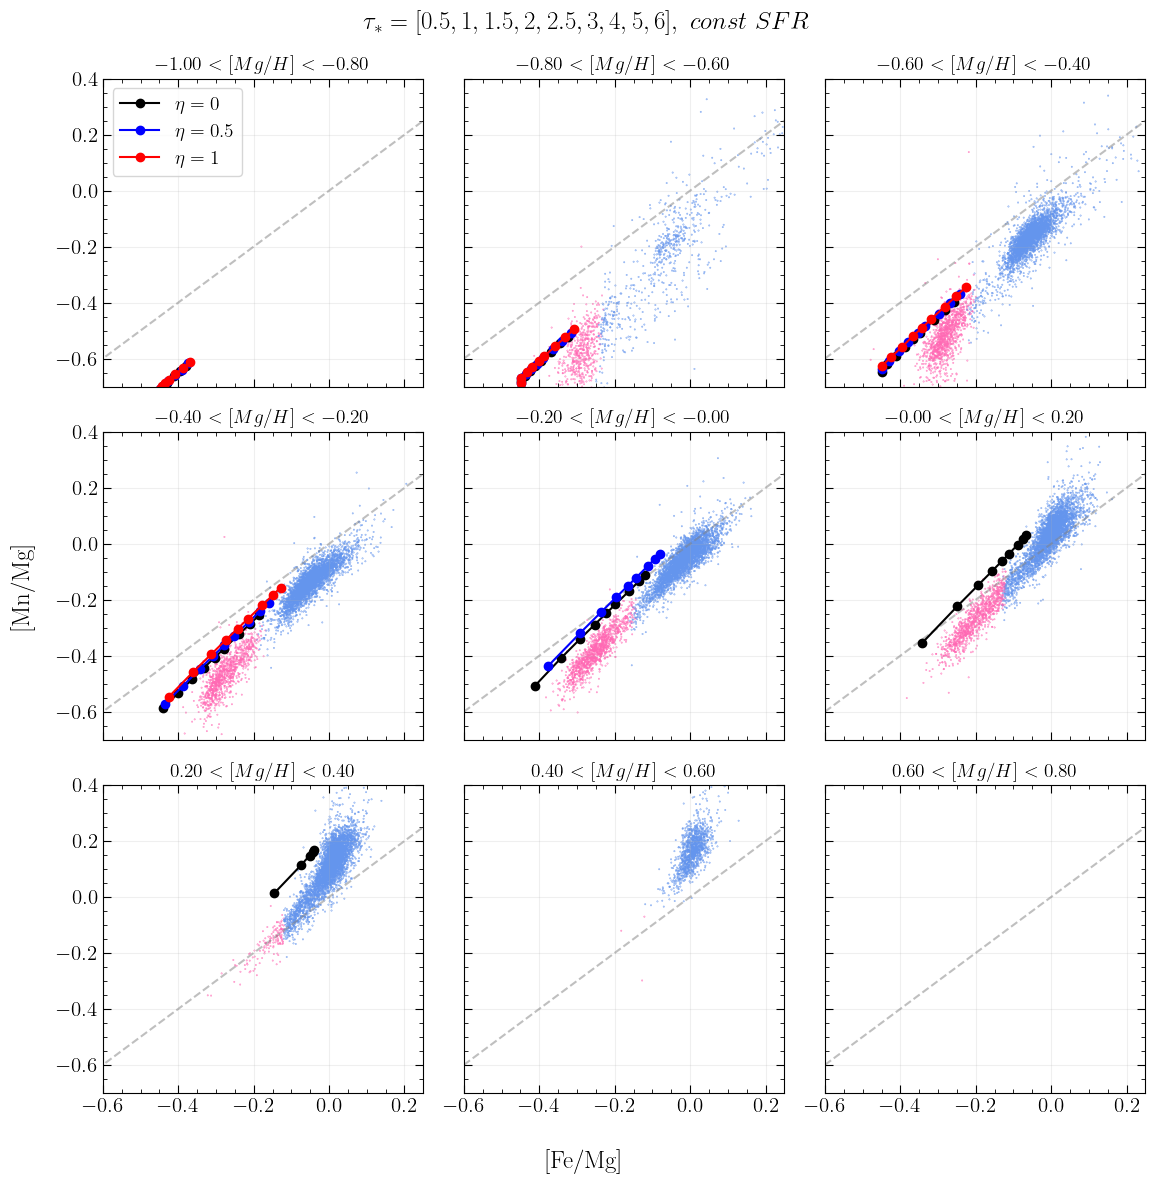

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    # Background data
    df = data_all[data_all['MG_H_big_bin'] == i]
    df = downsample(df, 5000)
    ax.scatter(df['FE_MG'], df['MN_MG'], s=0.1, color=df['color'])

    # 1:1 line
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, '--', alpha=0.5, color='gray')

    # τ_* sequence (η = 0 shown here)
    endpoints_0 = gals_endpoints[0][i]
    fe_mg_eta0 = []
    mn_mg_eta0 = []

    endpoints_1 = gals_endpoints[1][i]
    fe_mg_eta1 = []
    mn_mg_eta1 = []

    endpoints_2 = gals_endpoints[2][i]
    fe_mg_eta2 = []
    mn_mg_eta2 = []

    for gal, idx in zip(gals_taustar_eta0, endpoints_0):
        fe_mg_eta0.append(gal.Fe_Mg[idx])
        mn_mg_eta0.append(gal.Mn_Mg[idx])

    for gal, idx in zip(gals_taustar_eta1, endpoints_1):
        fe_mg_eta1.append(gal.Fe_Mg[idx])
        mn_mg_eta1.append(gal.Mn_Mg[idx])

    for gal, idx in zip(gals_taustar_eta2, endpoints_2):
        fe_mg_eta2.append(gal.Fe_Mg[idx])
        mn_mg_eta2.append(gal.Mn_Mg[idx])

    ax.plot(fe_mg_eta0, mn_mg_eta0, 'o-', color='black', linewidth=1.5, label = rf'$\eta = {etas[0]}$')
    ax.plot(fe_mg_eta1, mn_mg_eta1, 'o-', color='blue', linewidth=1.5, label = rf'$\eta = {etas[1]}$')
    ax.plot(fe_mg_eta2, mn_mg_eta2, 'o-', color='red', linewidth=1.5, label = rf'$\eta = {etas[2]}$')
    if i == 0:
        ax.legend()

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Mg]')
fig.suptitle(rf"$\tau_* = {tau_stars}, \ const\ SFR$")
plt.tight_layout()
plt.show()


In [17]:
colors_dots = [
    "#000000",  # black (maximum contrast)
    "#65FA33",  # white
    "#2E8B57",  # sea green
    "#FFD700",  # gold
    "#8B4513",  # saddle brown
    "#4B0082",  # indigo
    "#008080",  # teal
    "#B22222",  # firebrick
    "#2F4F4F",  # dark slate gray
    "#FF8C00",  # dark orange
]


In [18]:
gals_endpoints[0]

[array([ 4,  8, 11, 15, 19, 22, 30, 37, 44]),
 array([ 6, 12, 18, 24, 30, 36, 48, 60, 71]),
 array([ 10,  20,  29,  39,  49,  58,  78,  97, 116]),
 array([ 17,  33,  49,  65,  81,  97, 130, 162, 194]),
 array([ 28,  57,  85, 113, 141, 169, 225, 282, 338]),
 array([ 54, 108, 162, 216, 271, 325, 433, 541, 649]),
 array([173, 348, 522, 696, 871]),
 array([], dtype=float64),
 array([], dtype=float64)]

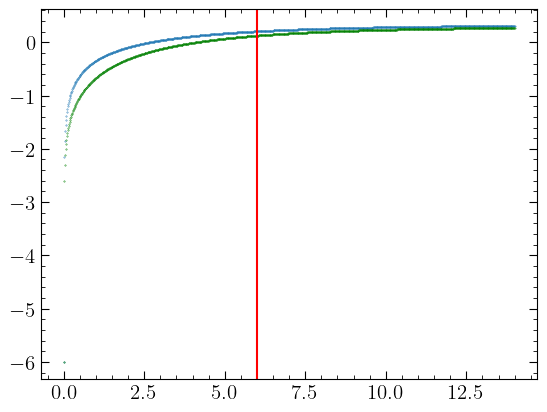

In [19]:
plt.scatter(gal.t, gal.O_H, s = 0.1)
plt.scatter(gal.t, gal.Fe_H, s = 0.1, color = 'green')
plt.axvline(6, color = 'red')

In [20]:
gals_endpoints_sfr = {
    "exp": find_endpoints(gals_taustar_sfrexp, mg_h_big_bin_centers),
    "1":   find_endpoints(gals_taustar_sfr1,   mg_h_big_bin_centers),
    "2":   find_endpoints(gals_taustar_sfr2,   mg_h_big_bin_centers),
    "3":   find_endpoints(gals_taustar_sfr3,   mg_h_big_bin_centers),
}


sfr_colors = {
    "exp": colors_dots[0],
    "1":   colors_dots[1],
    "2":   colors_dots[2],
    "3":   colors_dots[3],
}

sfr_labels = {
    "exp": r"exp SFR",
    "1":   r"SFR 1",
    "2":   r"SFR 2",
    "3":   r"SFR 3",
}

sfr_gal_lists = {
    "exp": gals_taustar_sfrexp,
    "1":   gals_taustar_sfr1,
    "2":   gals_taustar_sfr2,
    "3":   gals_taustar_sfr3,
}


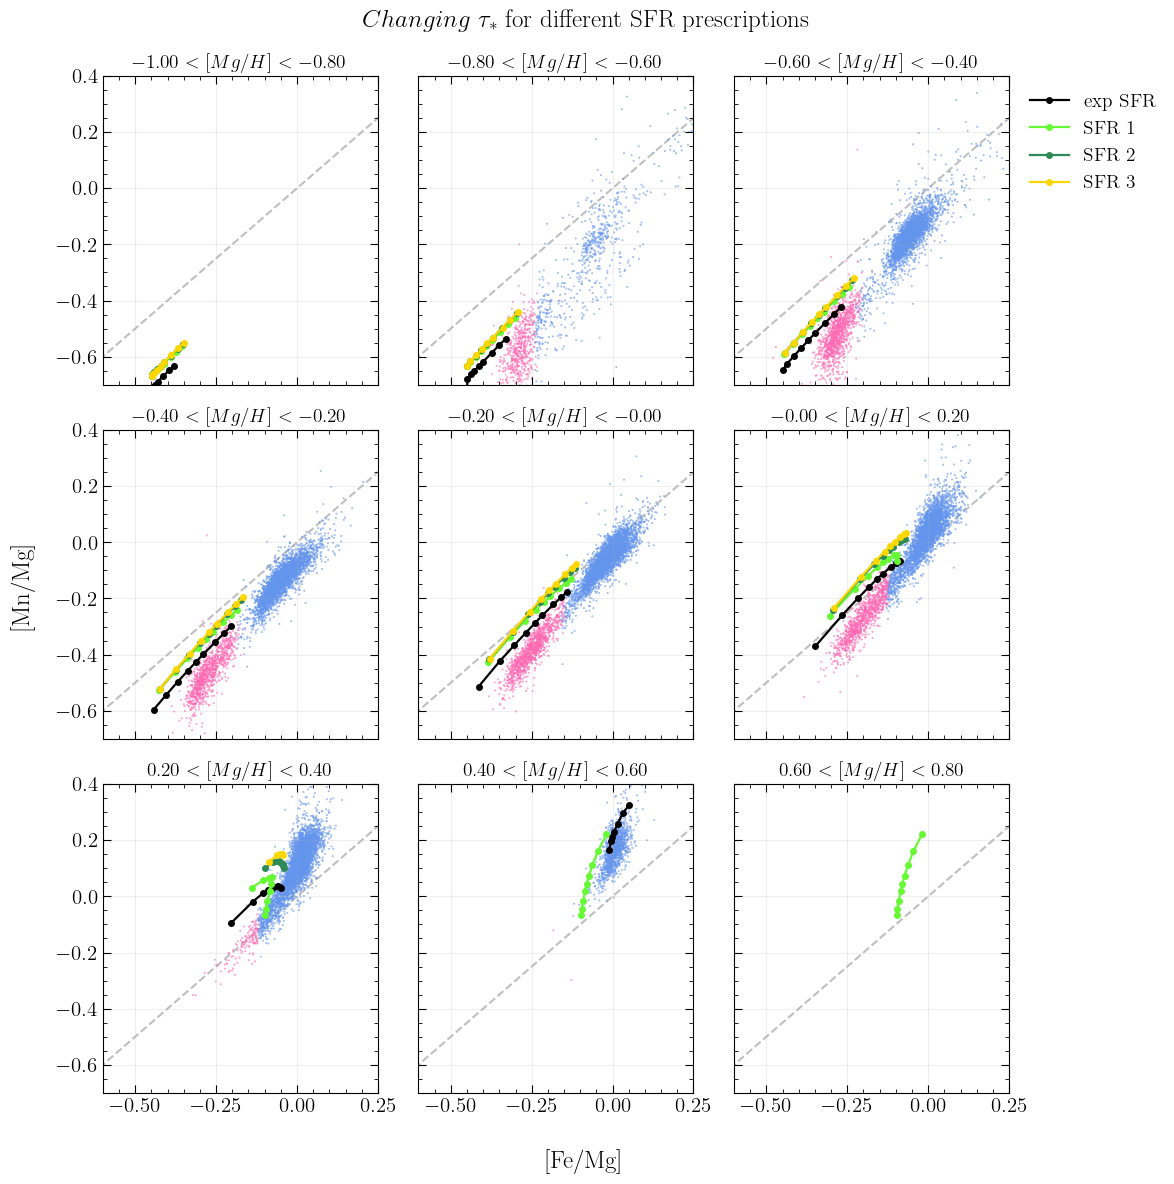

In [21]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):

    # --- background data ---
    df = data_all[data_all['MG_H_big_bin'] == i]
    df = downsample(df, 5000)
    ax.scatter(
        df['FE_MG'], df['MN_MG'],
        s=0.1,
        color=df['color'],
        zorder=1
    )

    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, '--', alpha=0.5, color='gray', zorder=0)

    # --- SFR tracks ---
    for sfr_key, color in sfr_colors.items():

        endpoints = gals_endpoints_sfr[sfr_key][i]
        galaxies  = sfr_gal_lists[sfr_key]

        fe_mg = []
        mn_mg = []

        for gal, idx in zip(galaxies, endpoints):
            fe_mg.append(gal.Fe_Mg[idx])
            mn_mg.append(gal.Mn_Mg[idx])

        ax.plot(
            fe_mg,
            mn_mg,
            color=color,
            marker='o',
            linewidth=1.6,
            markersize=4,
            label=sfr_labels[sfr_key],
            zorder=3
        )

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )

    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)

# Legend once
axes[2].legend(
    loc='upper right',
    bbox_to_anchor=(1.6, 1.0),
    frameon=False
)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Mg]')
fig.suptitle(r"$Changing\ \tau_* \ \mathrm{for\ different\ SFR\ prescriptions}$")
plt.tight_layout()
plt.show()


In [22]:
eta_markers = {
    0: 'o',
    1: 's',
    2: '^',
}

eta_labels = {
    0: rf'SFR const, $\eta = {etas[0]}$',
    1: rf'SFR const, $\eta = {etas[1]}$',
    2: rf'SFR const, $\eta = {etas[2]}$',
}

Text(0.02, 0.5, '[Mn/Mg]')

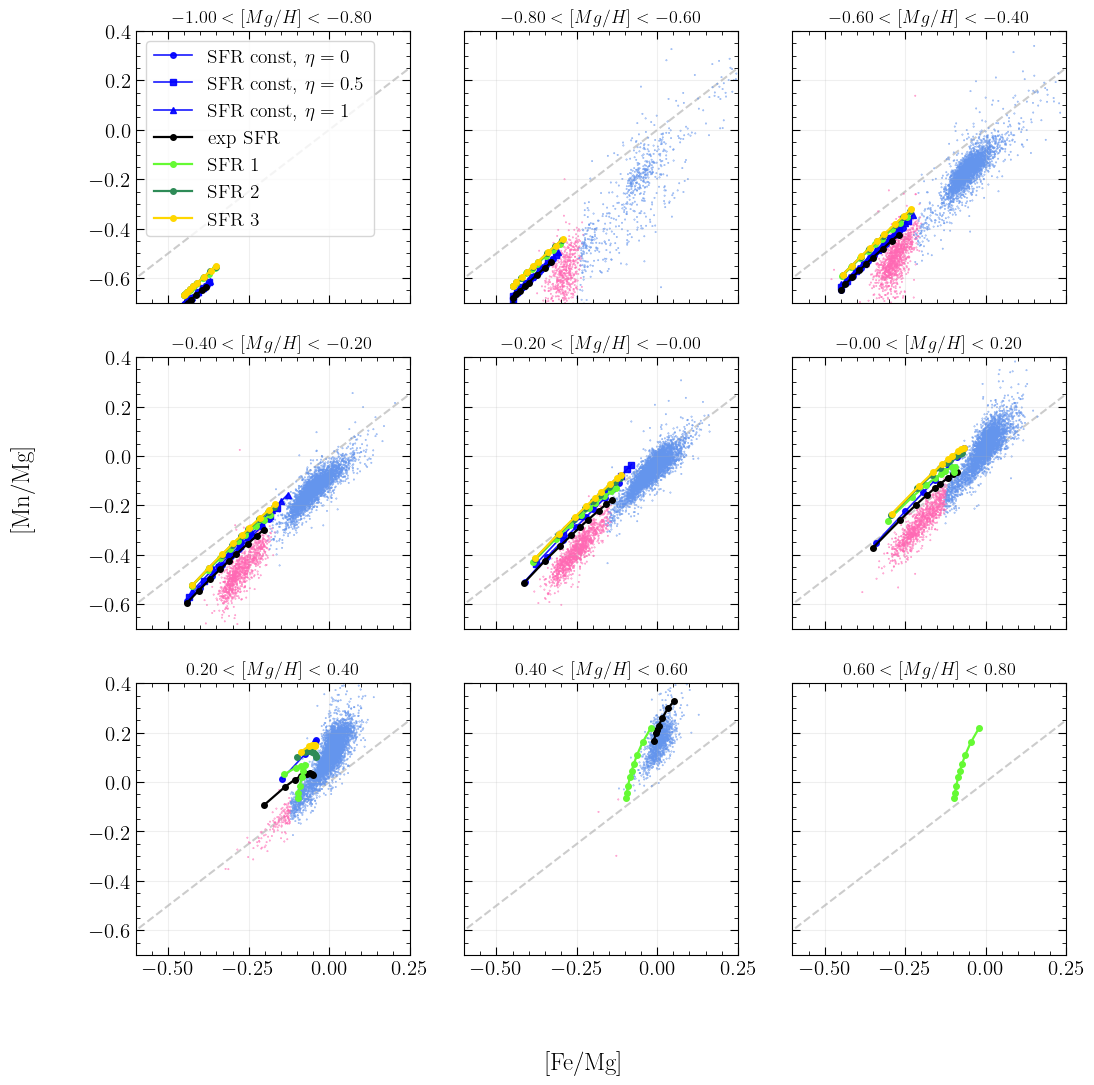

In [23]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):

    # --- background data ---
    df = data_all[data_all['MG_H_big_bin'] == i]
    df = downsample(df, 5000)
    ax.scatter(
        df['FE_MG'], df['MN_MG'],
        s=0.1,
        color=df['color'],
        zorder=1
    )

    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, '--', alpha=0.4, color='gray', zorder=0)

    # --- η tracks (const SFR) ---
    for eta_idx, marker in eta_markers.items():

        endpoints = gals_endpoints[eta_idx][i]
        galaxies  = [
            gals_taustar_eta0,
            gals_taustar_eta1,
            gals_taustar_eta2
        ][eta_idx]

        fe_mg, mn_mg = [], []

        for gal, idx in zip(galaxies, endpoints):
            fe_mg.append(gal.Fe_Mg[idx])
            mn_mg.append(gal.Mn_Mg[idx])

        ax.plot(
            fe_mg,
            mn_mg,
            color='blue',
            marker=marker,
            linewidth=1.2,
            markersize=4,
            alpha=0.9,
            label=eta_labels[eta_idx] if i == 0 else None,
            zorder=2
        )
        if i == 0:
            ax.legend()

    # --- SFR tracks ---
    for sfr_key, color in sfr_colors.items():

        endpoints = gals_endpoints_sfr[sfr_key][i]
        galaxies  = sfr_gal_lists[sfr_key]

        fe_mg, mn_mg = [], []

        for gal, idx in zip(galaxies, endpoints):
            fe_mg.append(gal.Fe_Mg[idx])
            mn_mg.append(gal.Mn_Mg[idx])

        ax.plot(
            fe_mg,
            mn_mg,
            color=color,
            marker='o',
            linewidth=1.6,
            markersize=4,
            label=sfr_labels[sfr_key] if i == 0 else None,
            zorder=3
        )
        if i == 0:
            ax.legend()



    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=13
    )

    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)


fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Mg]')

# Metallicity dependance parameters

In [24]:
def mn_mg_background():
    plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
    plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.01, color = 'pink', s = 0.5)
    plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'blue')
    plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'red')

    plt.grid('True', alpha = 0.2)
    plt.ylim(-0.65,0.25)
    plt.xlabel('[Mg/H]')
    plt.ylabel('[Mn/Mg]')
    plt.xlim(-1.05,0.55)

def fe_mg_background():
    plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
    plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.01, color = 'pink', s = 0.5)
    plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'blue')
    plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'red')

    plt.grid('True', alpha = 0.2)
    plt.ylim(-0.65,0.25)
    plt.xlabel('[Mg/H]')
    plt.ylabel('[Mn/Mg]')
    plt.xlim(-1.05,0.55)

## RIa

In [ ]:
R_Ias = [0, 1, 1.97, 4]
gals_RIa0 = []
gals_RIa1 = []
gals_RIa2 = []
gals_RIa3 = []

for i in range(len(tau_stars)):
    gals_RIa0.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0], R_Ia_Mn=R_Ias[0]))

for i in range(len(tau_stars)):
    gals_RIa1.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0], R_Ia_Mn=R_Ias[1]))

for i in range(len(tau_stars)):
    gals_RIa2.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0], R_Ia_Mn=R_Ias[2]))

for i in range(len(tau_stars)):
    gals_RIa3.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0], R_Ia_Mn=R_Ias[3]))

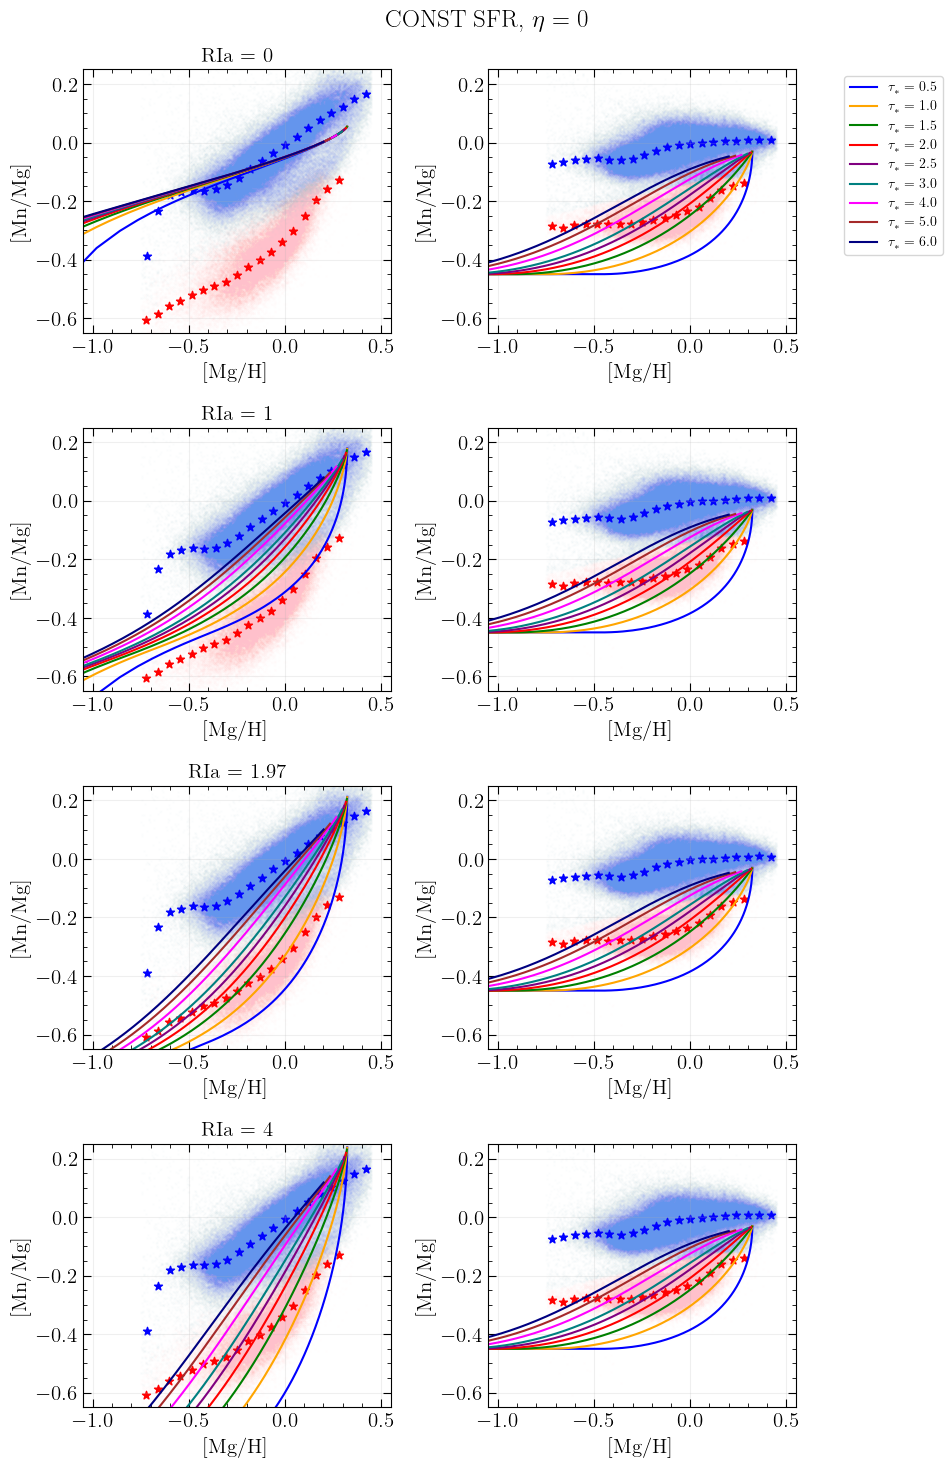

In [26]:
fig = plt.figure(figsize=(10,15))

#RIA0
plt.subplot(4,2,1)
mn_mg_background()
for i in range(len(gals_RIa0)):
    gal = gals_RIa0[i]
    plt.plot(gal.O_H, gal.Mn_O, label = rf'RIa = {R_Ias[0]}', color = colors_lines[i], linestyle='-')
plt.title(rf"RIa = {R_Ias[0]}")

plt.subplot(4,2,2)
fe_mg_background()
for i in range(len(gals_RIa0)):
    gal = gals_RIa0[i]
    plt.plot(gal.O_H, gal.Fe_O, label = rf'$\tau_* = {gal.tau_star_arr[0]}$', color = colors_lines[i])

plt.legend(bbox_to_anchor=[1.5, 1], fontsize=10)

#RIA1
plt.subplot(4,2,3)
mn_mg_background()
for i in range(len(gals_RIa1)):
    gal = gals_RIa1[i]
    plt.plot(gal.O_H, gal.Mn_O, color = colors_lines[i], linestyle='-')
plt.title(rf"RIa = {R_Ias[1]}")

plt.subplot(4,2,4)
fe_mg_background()
for i in range(len(gals_RIa1)):
    gal = gals_RIa1[i]
    plt.plot(gal.O_H, gal.Fe_O, color = colors_lines[i])

#RIA2
plt.subplot(4,2,5)
mn_mg_background()
for i in range(len(gals_RIa2)):
    gal = gals_RIa2[i]
    plt.plot(gal.O_H, gal.Mn_O, color = colors_lines[i])
plt.title(rf"RIa = {R_Ias[2]}")

plt.subplot(4,2,6)
fe_mg_background()
for i in range(len(gals_RIa2)):
    gal = gals_RIa2[i]
    plt.plot(gal.O_H, gal.Fe_O, color = colors_lines[i])


#RIA3
plt.subplot(4,2,7)
mn_mg_background()
for i in range(len(gals_RIa3)):
    gal = gals_RIa3[i]
    plt.plot(gal.O_H, gal.Mn_O, label = 'Mn, default met dep', color = colors_lines[i])
plt.title(rf"RIa = {R_Ias[3]}")

plt.subplot(4,2,8)
fe_mg_background()
for i in range(len(gals_RIa3)):
    gal = gals_RIa3[i]
    plt.plot(gal.O_H, gal.Fe_O, label = rf'const SFR, $\tau_* = {gal.tau_star_arr[0]} , \eta = {gal.eta_arr[0]} $', color = colors_lines[i])


plt.suptitle(r"CONST SFR, $\eta = 0$")
plt.tight_layout()

In [27]:
ria_endpoints = {
    0: find_endpoints(gals_RIa0, mg_h_big_bin_centers),
    1: find_endpoints(gals_RIa1, mg_h_big_bin_centers),
    2: find_endpoints(gals_RIa2, mg_h_big_bin_centers),
    3: find_endpoints(gals_RIa3, mg_h_big_bin_centers)
}

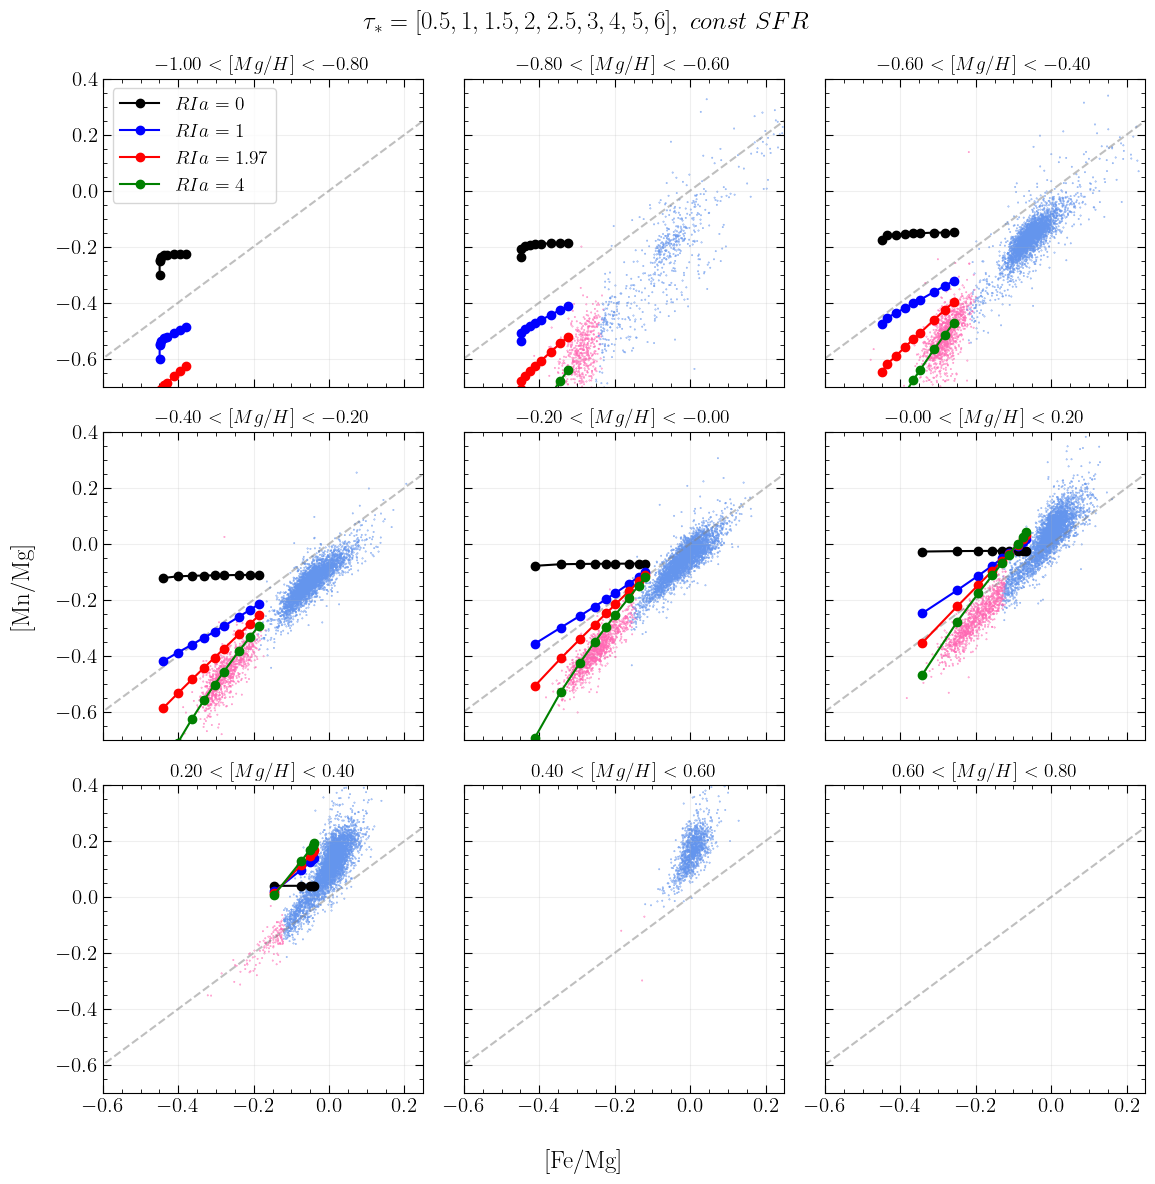

In [28]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    # Background data
    df = data_all[data_all['MG_H_big_bin'] == i]
    df = downsample(df, 5000)
    ax.scatter(df['FE_MG'], df['MN_MG'], s=0.1, color=df['color'])

    # 1:1 line
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, '--', alpha=0.5, color='gray')

    # τ_* sequence (η = 0 shown here)
    endpoints_0 = ria_endpoints[0][i]
    fe_mg_ria0 = []
    mn_mg_ria0 = []

    endpoints_1 = ria_endpoints[1][i]
    fe_mg_ria1 = []
    mn_mg_ria1 = []

    endpoints_2 = ria_endpoints[2][i]
    fe_mg_ria2 = []
    mn_mg_ria2 = []

    endpoints_3 = ria_endpoints[3][i]
    fe_mg_ria3 = []
    mn_mg_ria3 = []

    for gal, idx in zip(gals_RIa0, endpoints_0):
        fe_mg_ria0.append(gal.Fe_Mg[idx])
        mn_mg_ria0.append(gal.Mn_Mg[idx])

    for gal, idx in zip(gals_RIa1, endpoints_1):
        fe_mg_ria1.append(gal.Fe_Mg[idx])
        mn_mg_ria1.append(gal.Mn_Mg[idx])

    for gal, idx in zip(gals_RIa2, endpoints_2):
        fe_mg_ria2.append(gal.Fe_Mg[idx])
        mn_mg_ria2.append(gal.Mn_Mg[idx])

    for gal, idx in zip(gals_RIa3, endpoints_3):
        fe_mg_ria3.append(gal.Fe_Mg[idx])
        mn_mg_ria3.append(gal.Mn_Mg[idx])

    ax.plot(fe_mg_ria0, mn_mg_ria0, 'o-', color='black', linewidth=1.5, label = rf'$RIa = {R_Ias[0]}$')
    ax.plot(fe_mg_ria1, mn_mg_ria1, 'o-', color='blue', linewidth=1.5, label = rf'$RIa = {R_Ias[1]}$')
    ax.plot(fe_mg_ria2, mn_mg_ria2, 'o-', color='red', linewidth=1.5, label = rf'$RIa = {R_Ias[2]}$')
    ax.plot(fe_mg_ria3, mn_mg_ria3, 'o-', color='green', linewidth=1.5, label = rf'$RIa = {R_Ias[3]}$')
    if i == 0:
        ax.legend()

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Mg]')
fig.suptitle(rf"$\tau_* = {tau_stars}, \ const\ SFR$")
plt.tight_layout()
plt.show()


## alphaCC

In [29]:
alpha_ccs = [0, 0.17, 0.5, 1]

gals_alphacc0 = []
gals_alphacc1 = []
gals_alphacc2 = []
gals_alphacc3 = []

for i in range(len(tau_stars)):
    gals_alphacc0.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0], alpha_cc_Mn=alpha_ccs[0]))

for i in range(len(tau_stars)):
    gals_alphacc1.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0], alpha_cc_Mn=alpha_ccs[1]))

for i in range(len(tau_stars)):
    gals_alphacc2.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0], alpha_cc_Mn=alpha_ccs[2]))

for i in range(len(tau_stars)):
    gals_alphacc3.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0], alpha_cc_Mn=alpha_ccs[3]))

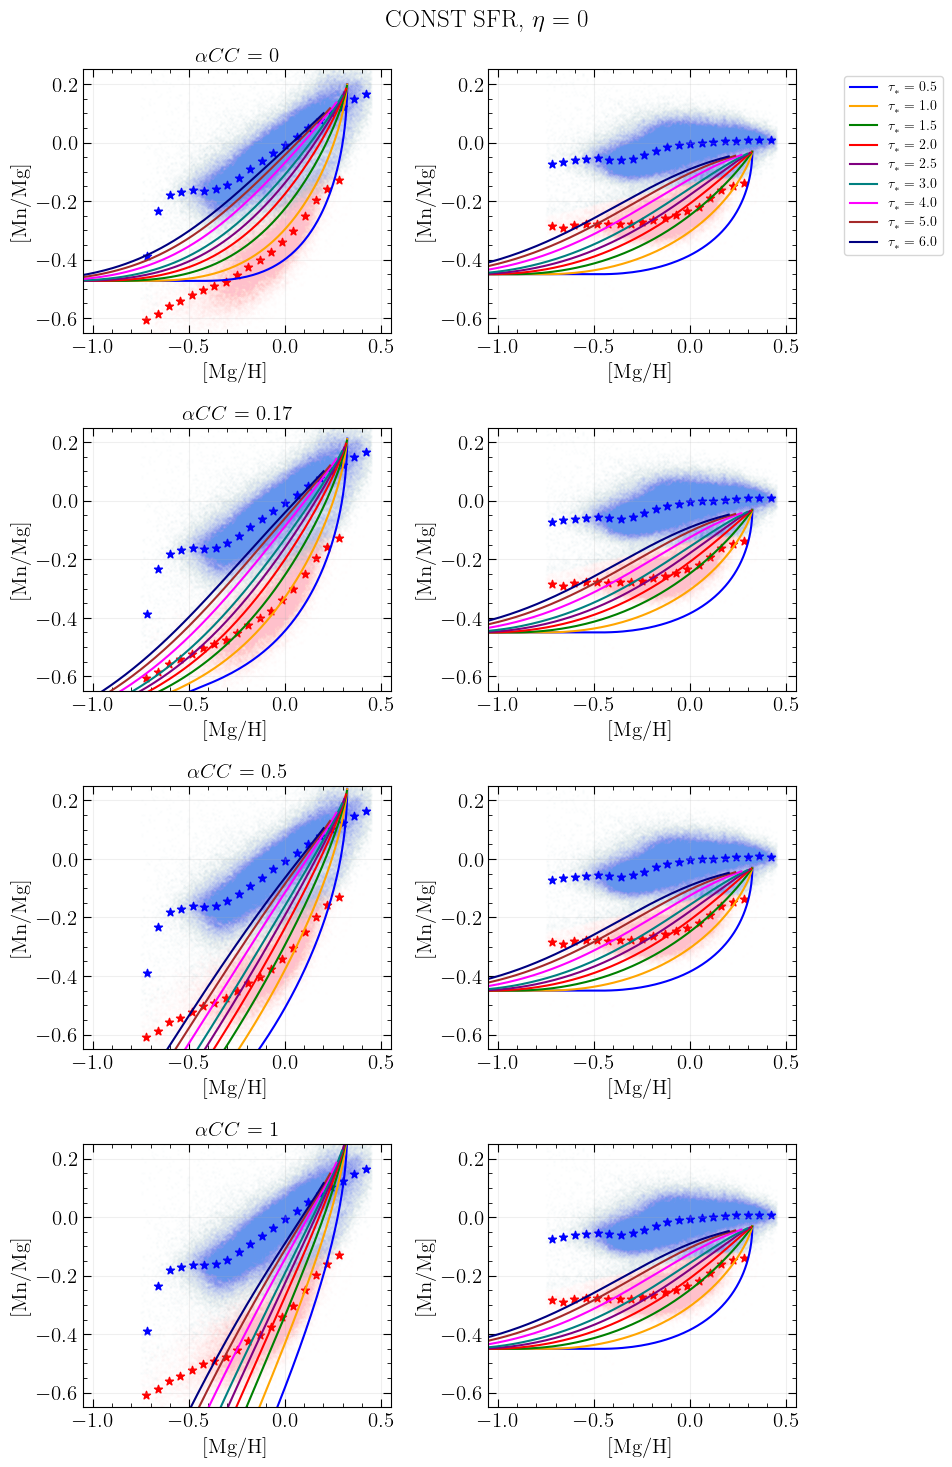

In [30]:
fig = plt.figure(figsize=(10,15))

#alphacc0
plt.subplot(4,2,1)
mn_mg_background()
for i in range(len(gals_alphacc0)):
    gal = gals_alphacc0[i]
    plt.plot(gal.O_H, gal.Mn_O, color = colors_lines[i], linestyle='-')
plt.title(rf"$\alpha CC $ = {alpha_ccs[0]}")

plt.subplot(4,2,2)
fe_mg_background()
for i in range(len(gals_alphacc0)):
    gal = gals_alphacc0[i]
    plt.plot(gal.O_H, gal.Fe_O, label = rf'$\tau_* = {gal.tau_star_arr[0]}$', color = colors_lines[i])

plt.legend(bbox_to_anchor=[1.5, 1], fontsize=10)

#alphacc1
plt.subplot(4,2,3)
mn_mg_background()
for i in range(len(gals_alphacc1)):
    gal = gals_alphacc1[i]
    plt.plot(gal.O_H, gal.Mn_O, color = colors_lines[i], linestyle='-')
plt.title(rf"$\alpha CC $ = {alpha_ccs[1]}")

plt.subplot(4,2,4)
fe_mg_background()
for i in range(len(gals_alphacc1)):
    gal = gals_alphacc1[i]
    plt.plot(gal.O_H, gal.Fe_O, color = colors_lines[i])

#alphacc2
plt.subplot(4,2,5)
mn_mg_background()
for i in range(len(gals_alphacc2)):
    gal = gals_alphacc2[i]
    plt.plot(gal.O_H, gal.Mn_O, color = colors_lines[i])
plt.title(rf"$\alpha CC $ = {alpha_ccs[2]}")

plt.subplot(4,2,6)
fe_mg_background()
for i in range(len(gals_alphacc2)):
    gal = gals_alphacc2[i]
    plt.plot(gal.O_H, gal.Fe_O, color = colors_lines[i])


#alphacc3
plt.subplot(4,2,7)
mn_mg_background()
for i in range(len(gals_alphacc3)):
    gal = gals_alphacc3[i]
    plt.plot(gal.O_H, gal.Mn_O, label = 'Mn, default met dep', color = colors_lines[i])
plt.title(rf"$\alpha CC $ = {alpha_ccs[3]}")

plt.subplot(4,2,8)
fe_mg_background()
for i in range(len(gals_alphacc3)):
    gal = gals_alphacc3[i]
    plt.plot(gal.O_H, gal.Fe_O, label = rf'const SFR, $\tau_* = {gal.tau_star_arr[0]} , \eta = {gal.eta_arr[0]} $', color = colors_lines[i])


plt.suptitle(r"CONST SFR, $\eta = 0$")
plt.tight_layout()

In [31]:
alphacc_endpoints = {
    0: find_endpoints(gals_alphacc0, mg_h_big_bin_centers),
    1: find_endpoints(gals_alphacc1, mg_h_big_bin_centers),
    2: find_endpoints(gals_alphacc2, mg_h_big_bin_centers),
    3: find_endpoints(gals_alphacc3, mg_h_big_bin_centers)
}

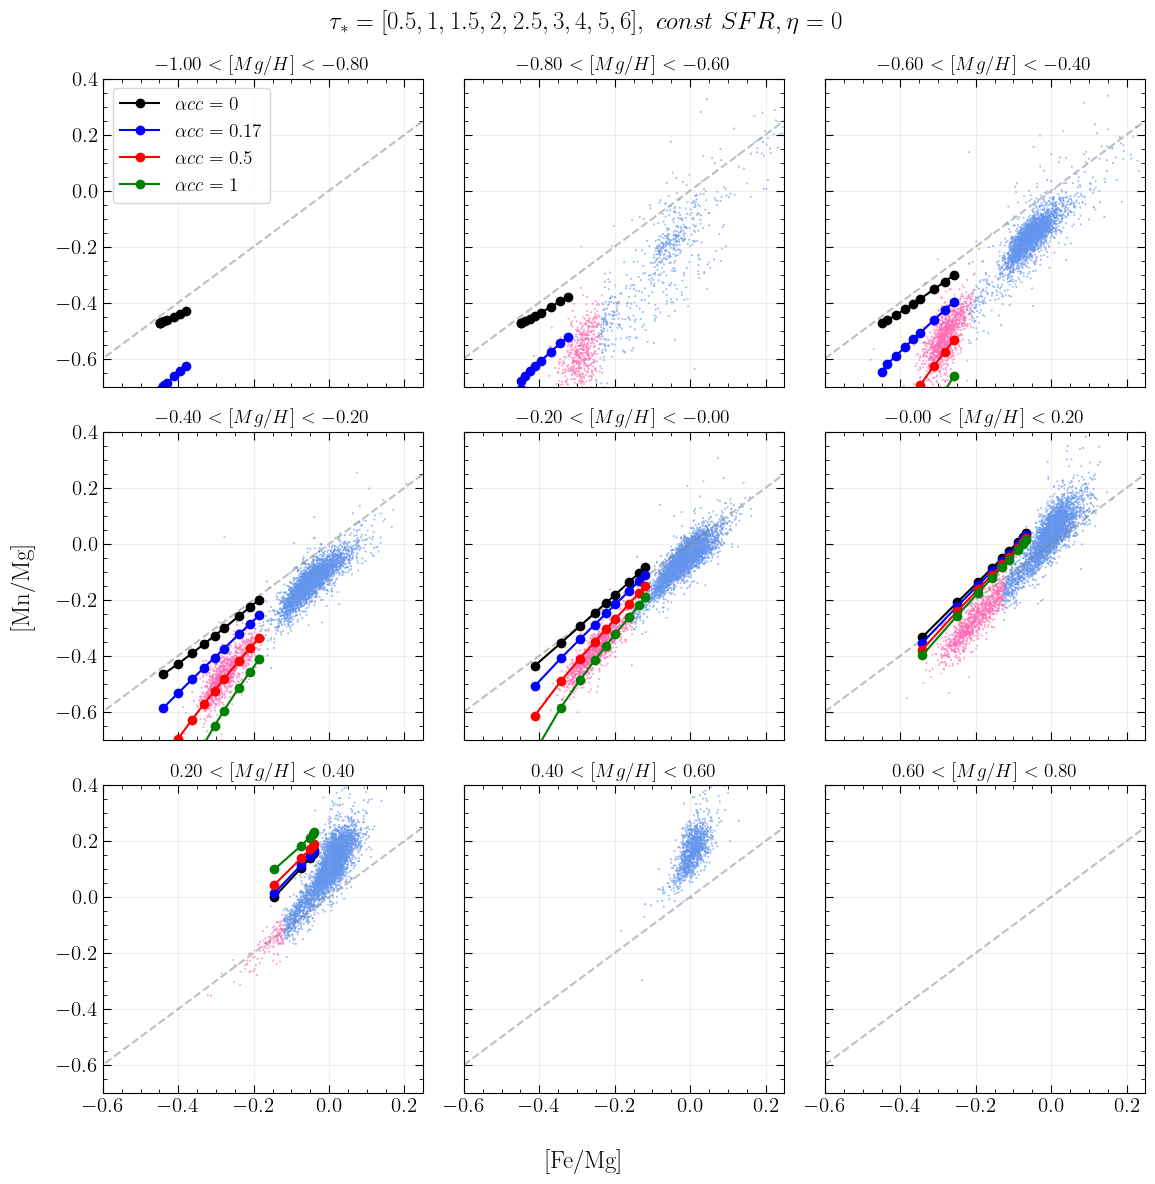

In [32]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    # Background data
    df = data_all[data_all['MG_H_big_bin'] == i]
    df = downsample(df, 5000)
    ax.scatter(df['FE_MG'], df['MN_MG'], s=0.1, color=df['color'])

    # 1:1 line
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, '--', alpha=0.5, color='gray')

    # τ_* sequence (η = 0 shown here)
    endpoints_0 = alphacc_endpoints[0][i]
    fe_mg_alphacc0 = []
    mn_mg_alphacc0 = []

    endpoints_1 = alphacc_endpoints[1][i]
    fe_mg_alphacc1 = []
    mn_mg_alphacc1 = []

    endpoints_2 = alphacc_endpoints[2][i]
    fe_mg_alphacc2 = []
    mn_mg_alphacc2 = []

    endpoints_3 = alphacc_endpoints[3][i]
    fe_mg_alphacc3 = []
    mn_mg_alphacc3 = []

    for gal, idx in zip(gals_alphacc0, endpoints_0):
        fe_mg_alphacc0.append(gal.Fe_Mg[idx])
        mn_mg_alphacc0.append(gal.Mn_Mg[idx])

    for gal, idx in zip(gals_alphacc1, endpoints_1):
        fe_mg_alphacc1.append(gal.Fe_Mg[idx])
        mn_mg_alphacc1.append(gal.Mn_Mg[idx])

    for gal, idx in zip(gals_alphacc2, endpoints_2):
        fe_mg_alphacc2.append(gal.Fe_Mg[idx])
        mn_mg_alphacc2.append(gal.Mn_Mg[idx])

    for gal, idx in zip(gals_alphacc3, endpoints_3):
        fe_mg_alphacc3.append(gal.Fe_Mg[idx])
        mn_mg_alphacc3.append(gal.Mn_Mg[idx])

    ax.plot(fe_mg_alphacc0, mn_mg_alphacc0, 'o-', color='black', linewidth=1.5, label = rf'$\alpha cc = {alpha_ccs[0]}$')
    ax.plot(fe_mg_alphacc1, mn_mg_alphacc1, 'o-', color='blue', linewidth=1.5, label = rf'$\alpha cc = {alpha_ccs[1]}$')
    ax.plot(fe_mg_alphacc2, mn_mg_alphacc2, 'o-', color='red', linewidth=1.5, label = rf'$\alpha cc = {alpha_ccs[2]}$')
    ax.plot(fe_mg_alphacc3, mn_mg_alphacc3, 'o-', color='green', linewidth=1.5, label = rf'$\alpha cc = {alpha_ccs[3]}$')
    if i == 0:
        ax.legend()

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Mg]')
fig.suptitle(rf"$\tau_* = {tau_stars}, \ const\ SFR, \eta = 0$")
plt.tight_layout()
plt.show()


## alphaIa

In [33]:
alpha_ias = [0, 0.3, 0.6, 1]

gals_alphaia0 = []
gals_alphaia1 = []
gals_alphaia2 = []
gals_alphaia3 = []

for i in range(len(tau_stars)):
    gals_alphaia0.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0], alpha_Ia_Mn=alpha_ias[0]))

for i in range(len(tau_stars)):
    gals_alphaia1.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0], alpha_Ia_Mn=alpha_ias[1]))

for i in range(len(tau_stars)):
    gals_alphaia2.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0], alpha_Ia_Mn=alpha_ias[2]))

for i in range(len(tau_stars)):
    gals_alphaia3.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0], alpha_Ia_Mn=alpha_ias[3]))

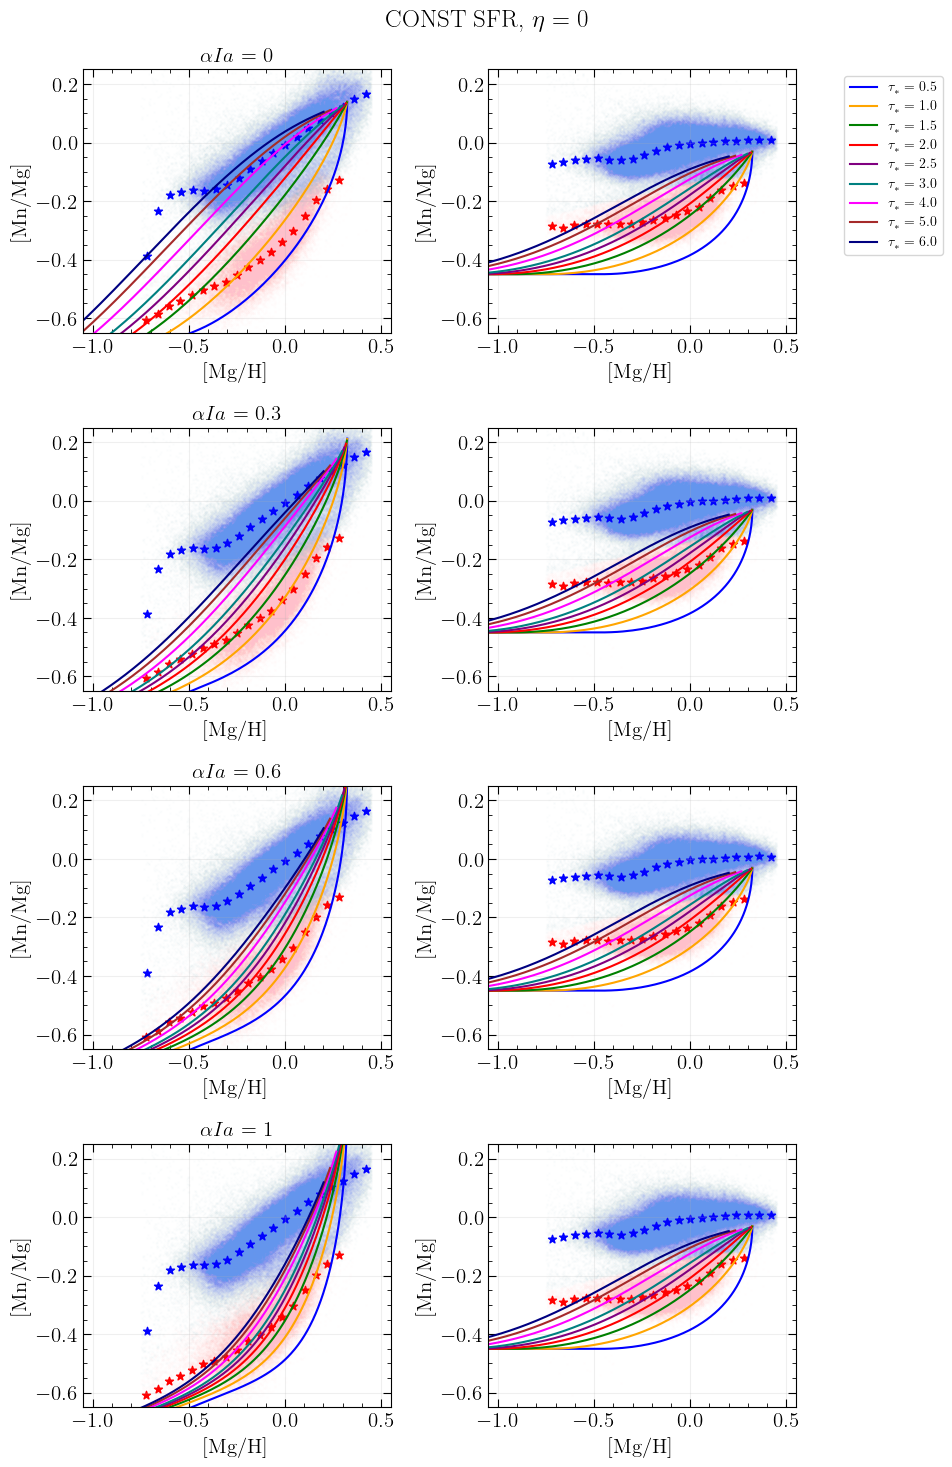

In [34]:
fig = plt.figure(figsize=(10,15))

#alphaia0
plt.subplot(4,2,1)
mn_mg_background()
for i in range(len(gals_alphaia0)):
    gal = gals_alphaia0[i]
    plt.plot(gal.O_H, gal.Mn_O, color = colors_lines[i], linestyle='-')
plt.title(rf"$\alpha Ia $ = {alpha_ias[0]}")

plt.subplot(4,2,2)
fe_mg_background()
for i in range(len(gals_alphaia0)):
    gal = gals_alphaia0[i]
    plt.plot(gal.O_H, gal.Fe_O, label = rf'$\tau_* = {gal.tau_star_arr[0]}$', color = colors_lines[i])

plt.legend(bbox_to_anchor=[1.5, 1], fontsize=10)

#alphaia1
plt.subplot(4,2,3)
mn_mg_background()
for i in range(len(gals_alphaia1)):
    gal = gals_alphaia1[i]
    plt.plot(gal.O_H, gal.Mn_O, color = colors_lines[i], linestyle='-')
plt.title(rf"$\alpha Ia $ = {alpha_ias[1]}")

plt.subplot(4,2,4)
fe_mg_background()
for i in range(len(gals_alphaia1)):
    gal = gals_alphaia1[i]
    plt.plot(gal.O_H, gal.Fe_O, color = colors_lines[i])

#alphaia2
plt.subplot(4,2,5)
mn_mg_background()
for i in range(len(gals_alphaia2)):
    gal = gals_alphaia2[i]
    plt.plot(gal.O_H, gal.Mn_O, color = colors_lines[i])
plt.title(rf"$\alpha Ia $ = {alpha_ias[2]}")

plt.subplot(4,2,6)
fe_mg_background()
for i in range(len(gals_alphaia2)):
    gal = gals_alphaia2[i]
    plt.plot(gal.O_H, gal.Fe_O, color = colors_lines[i])


#alphacc3
plt.subplot(4,2,7)
mn_mg_background()
for i in range(len(gals_alphaia3)):
    gal = gals_alphaia3[i]
    plt.plot(gal.O_H, gal.Mn_O, label = 'Mn, default met dep', color = colors_lines[i])
plt.title(rf"$\alpha Ia $ = {alpha_ias[3]}")

plt.subplot(4,2,8)
fe_mg_background()
for i in range(len(gals_alphaia3)):
    gal = gals_alphaia3[i]
    plt.plot(gal.O_H, gal.Fe_O, label = rf'const SFR, $\tau_* = {gal.tau_star_arr[0]} , \eta = {gal.eta_arr[0]} $', color = colors_lines[i])


plt.suptitle(r"CONST SFR, $\eta = 0$")
plt.tight_layout()

In [35]:
alphaia_endpoints = {
    0: find_endpoints(gals_alphaia0, mg_h_big_bin_centers),
    1: find_endpoints(gals_alphaia1, mg_h_big_bin_centers),
    2: find_endpoints(gals_alphaia2, mg_h_big_bin_centers),
    3: find_endpoints(gals_alphaia3, mg_h_big_bin_centers)
}

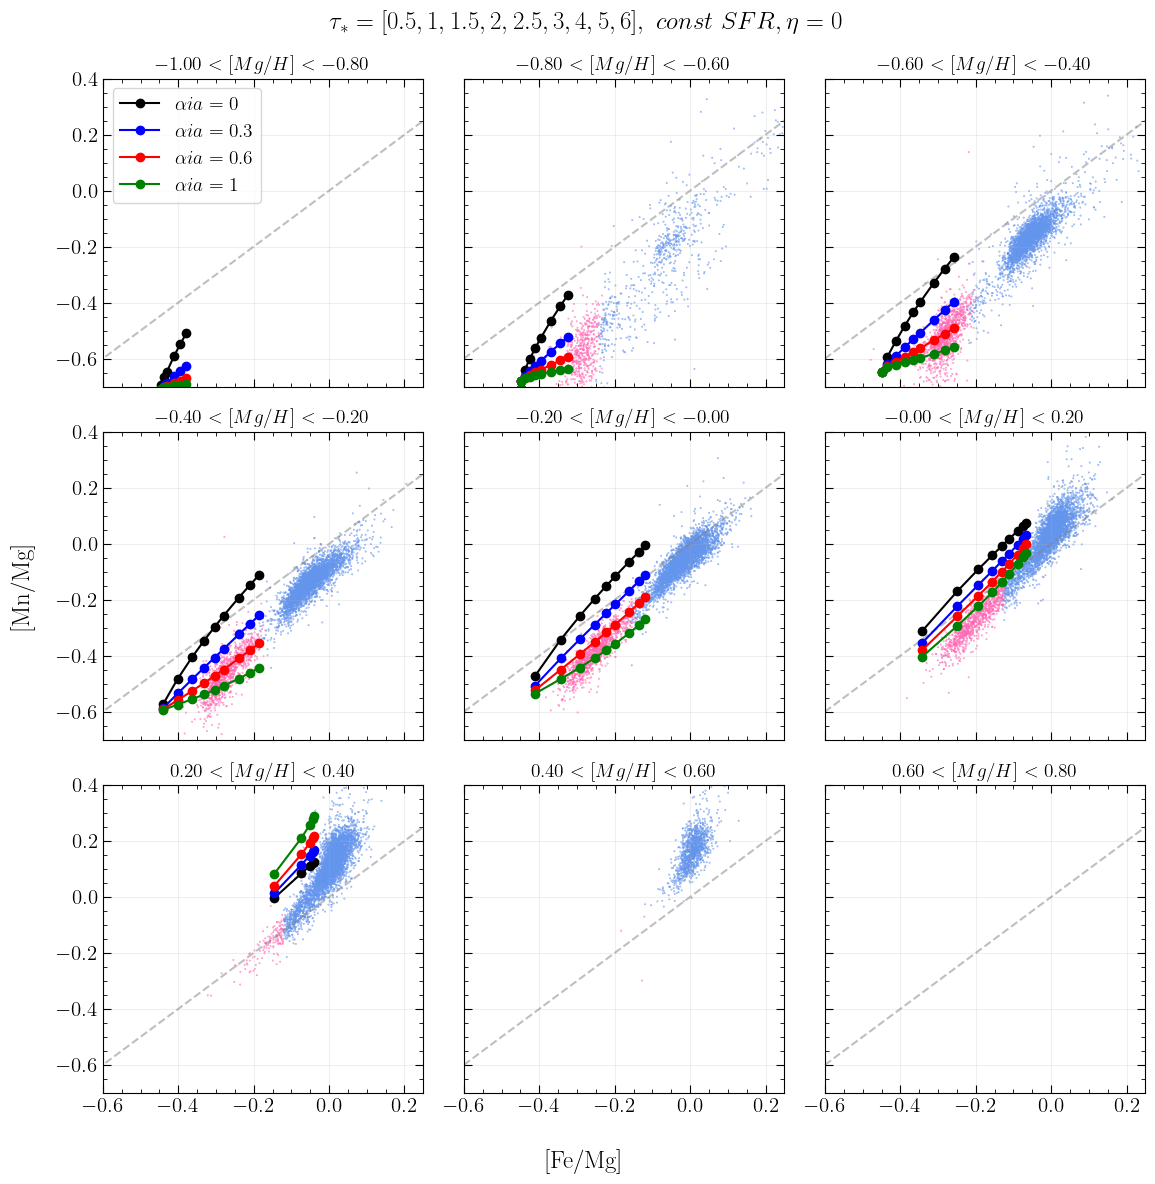

In [36]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    # Background data
    df = data_all[data_all['MG_H_big_bin'] == i]
    df = downsample(df, 5000)
    ax.scatter(df['FE_MG'], df['MN_MG'], s=0.1, color=df['color'])

    # 1:1 line
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, '--', alpha=0.5, color='gray')

    # τ_* sequence (η = 0 shown here)
    endpoints_0 = alphaia_endpoints[0][i]
    fe_mg_alphaia0 = []
    mn_mg_alphaia0 = []

    endpoints_1 = alphaia_endpoints[1][i]
    fe_mg_alphaia1 = []
    mn_mg_alphaia1 = []

    endpoints_2 = alphaia_endpoints[2][i]
    fe_mg_alphaia2 = []
    mn_mg_alphaia2 = []

    endpoints_3 = alphaia_endpoints[3][i]
    fe_mg_alphaia3 = []
    mn_mg_alphaia3 = []

    for gal, idx in zip(gals_alphaia0, endpoints_0):
        fe_mg_alphaia0.append(gal.Fe_Mg[idx])
        mn_mg_alphaia0.append(gal.Mn_Mg[idx])

    for gal, idx in zip(gals_alphaia1, endpoints_1):
        fe_mg_alphaia1.append(gal.Fe_Mg[idx])
        mn_mg_alphaia1.append(gal.Mn_Mg[idx])

    for gal, idx in zip(gals_alphaia2, endpoints_2):
        fe_mg_alphaia2.append(gal.Fe_Mg[idx])
        mn_mg_alphaia2.append(gal.Mn_Mg[idx])

    for gal, idx in zip(gals_alphaia3, endpoints_3):
        fe_mg_alphaia3.append(gal.Fe_Mg[idx])
        mn_mg_alphaia3.append(gal.Mn_Mg[idx])

    ax.plot(fe_mg_alphaia0, mn_mg_alphaia0, 'o-', color='black', linewidth=1.5, label = rf'$\alpha ia = {alpha_ias[0]}$')
    ax.plot(fe_mg_alphaia1, mn_mg_alphaia1, 'o-', color='blue', linewidth=1.5, label = rf'$\alpha ia = {alpha_ias[1]}$')
    ax.plot(fe_mg_alphaia2, mn_mg_alphaia2, 'o-', color='red', linewidth=1.5, label = rf'$\alpha ia = {alpha_ias[2]}$')
    ax.plot(fe_mg_alphaia3, mn_mg_alphaia3, 'o-', color='green', linewidth=1.5, label = rf'$\alpha ia = {alpha_ias[3]}$')
    if i == 0:
        ax.legend()

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Mg]')
fig.suptitle(rf"$\tau_* = {tau_stars}, \ const\ SFR, \eta = 0$")
plt.tight_layout()
plt.show()
